In [72]:
from utils.data_utils import MnistDataloader
from os.path import join

import numpy as np
import matplotlib.pyplot as plt

## Loading the Data

In [73]:
input_path = './input'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images.idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels.idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images.idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels.idx1-ubyte')

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

x_train = np.array(x_train) 
x_test = np.array(x_test)

x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

x_train = x_train / x_train.max()
x_test = x_test / x_test.max()

x_train.shape, x_test.shape

((60000, 784), (10000, 784))

## Building the Network

In [74]:
def relu(input):
    return np.maximum(0, input)

class Layer:
    def __init__(self, weights, biases):
        self.weights = weights
        self.biases = biases
    
    def forward(self, input):
        dot_product = np.dot(input, self.weights)
        return dot_product + self.biases

class ReluLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
    
    def forward(self, input):
        result = super().forward(input)
        return relu(result)

In [75]:
def initialize_layers(input_size, hidden1_size, hidden2_size, latent_size, hidden3_size, hidden4_size, output_size):
    hidden1_weights = np.random.normal(0, np.sqrt(2.0 / input_size), size=(input_size, hidden1_size))
    hidden1_biases = np.zeros(shape=(hidden1_size,))
    hidden1_layer = ReluLayer(hidden1_weights, hidden1_biases)

    hidden2_weights = np.random.normal(0, np.sqrt(2.0 / hidden1_size), size=(hidden1_size, hidden2_size))
    hidden2_biases = np.zeros(shape=(hidden2_size,))
    hidden2_layer = ReluLayer(hidden2_weights, hidden2_biases)

    latent_weights = np.random.normal(0, np.sqrt(2.0 / hidden2_size), size=(hidden2_size, latent_size))
    latent_biases = np.zeros(shape=(latent_size,))
    latent_layer = ReluLayer(latent_weights, latent_biases)
    
    hidden3_weights = np.random.normal(0, np.sqrt(2.0 / latent_size), size=(latent_size, hidden3_size))
    hidden3_biases = np.zeros(shape=(hidden3_size,))
    hidden3_layer = ReluLayer(hidden3_weights, hidden3_biases)
    
    hidden4_weights = np.random.normal(0, np.sqrt(2.0 / hidden3_size), size=(hidden3_size, hidden4_size))
    hidden4_biases = np.zeros(shape=(hidden4_size,))
    hidden4_layer = ReluLayer(hidden4_weights, hidden4_biases)
    
    output_weights = np.random.normal(0, np.sqrt(2.0 / hidden4_size), size=(hidden4_size, output_size))
    output_biases = np.zeros(shape=(output_size,))
    output_layer = ReluLayer(output_weights, output_biases)

    return hidden1_layer, hidden2_layer, latent_layer, hidden3_layer, hidden4_layer, output_layer

In [76]:
layer_sizes = [784, 256, 64, 36, 64, 256, 784]

In [77]:
hidden1_layer, hidden2_layer, latent_layer, hidden3_layer, hidden4_layer, output_layer = initialize_layers(layer_sizes[0], layer_sizes[1], layer_sizes[2], layer_sizes[3], layer_sizes[4], layer_sizes[5], layer_sizes[6])

In [78]:
def forward(input):
    hidden1_output = hidden1_layer.forward(input)
    hidden2_output = hidden2_layer.forward(hidden1_output)
    latent_output = latent_layer.forward(hidden2_output)
    hidden3_output = hidden3_layer.forward(latent_output)
    hidden4_output = hidden4_layer.forward(hidden3_output)
    output = output_layer.forward(hidden4_output)
    return hidden1_output, hidden2_output, latent_output, hidden3_output, hidden4_output, output

In [79]:
def clip_grad(grad, clip_value=5.0):
    norm = np.linalg.norm(grad)
    if norm > clip_value:
        grad = grad * (clip_value / norm)
    return grad

def backward(input, hidden1_output, hidden2_output, latent_output, hidden3_output, hidden4_output, output, target):
    output_error = output - target * (output > 0)
    output_w_grad = hidden4_output.T @ output_error
    output_b_grad = np.mean(output_error, axis=0)

    hidden4_error = np.dot(output_error, output_layer.weights.T) * (hidden4_output > 0)
    hidden4_w_grad = hidden3_output.T @ hidden4_error
    hidden4_b_grad = np.mean(hidden4_error, axis=0)
    
    hidden3_error = np.dot(hidden4_error, hidden4_layer.weights.T) * (hidden3_output > 0)
    hidden3_w_grad = latent_output.T @ hidden3_error
    hidden3_b_grad = np.mean(hidden3_error, axis=0)

    latent_error = np.dot(hidden3_error, hidden3_layer.weights.T) * (latent_output > 0)    
    latent_w_grad = hidden2_output.T @ latent_error
    latent_b_grad = np.mean(latent_error, axis=0)
    
    hidden2_error = np.dot(latent_error, latent_layer.weights.T) * (hidden2_output > 0)
    hidden2_w_grad = hidden1_output.T @ hidden2_error
    hidden2_b_grad = np.mean(hidden2_error, axis=0)
    
    hidden1_error = np.dot(hidden2_error, hidden2_layer.weights.T) * (hidden1_output > 0)
    hidden1_w_grad = input.T @ hidden1_error
    hidden1_b_grad = np.mean(hidden1_error, axis=0)
    
    output_w_grad = clip_grad(output_w_grad)
    output_b_grad = clip_grad(output_b_grad)
    hidden4_w_grad = clip_grad(hidden4_w_grad)
    hidden4_b_grad = clip_grad(hidden4_b_grad)
    hidden3_w_grad = clip_grad(hidden3_w_grad)
    hidden3_b_grad = clip_grad(hidden3_b_grad)
    latent_w_grad = clip_grad(latent_w_grad)
    latent_b_grad = clip_grad(latent_b_grad)
    hidden2_w_grad = clip_grad(hidden2_w_grad)
    hidden2_b_grad = clip_grad(hidden2_b_grad)
    hidden1_w_grad = clip_grad(hidden1_w_grad)
    hidden1_b_grad = clip_grad(hidden1_b_grad)

    return hidden1_w_grad, hidden1_b_grad, hidden2_w_grad, hidden2_b_grad, latent_w_grad, latent_b_grad, hidden3_w_grad, hidden3_b_grad, hidden4_w_grad, hidden4_b_grad, output_w_grad, output_b_grad

In [80]:
def update_parameters(learning_rate, hidden1_w_grad, hidden1_b_grad, hidden2_w_grad, hidden2_b_grad, latent_w_grad, latent_b_grad, hidden3_w_grad, hidden3_b_grad, hidden4_w_grad, hidden4_b_grad, output_w_grad, output_b_grad):
    global output_layer, hidden4_layer, hidden3_layer, latent_layer, hidden2_layer, hidden1_layer

    output_layer.weights -= output_w_grad * learning_rate
    output_layer.biases -= output_b_grad * learning_rate

    hidden4_layer.weights -= hidden4_w_grad * learning_rate
    hidden4_layer.biases -= hidden4_b_grad * learning_rate

    hidden3_layer.weights -= hidden3_w_grad * learning_rate
    hidden3_layer.biases -= hidden3_b_grad * learning_rate

    latent_layer.weights -= latent_w_grad * learning_rate
    latent_layer.biases -= latent_b_grad * learning_rate

    hidden2_layer.weights -= hidden2_w_grad * learning_rate
    hidden2_layer.biases -= hidden2_b_grad * learning_rate

    hidden1_layer.weights -= hidden1_w_grad * learning_rate
    hidden1_layer.biases -= hidden1_b_grad * learning_rate

In [81]:
def compute_loss(output, target):
    return np.mean((output - target) ** 2)

## Training the Network

In [82]:
def train(x_train, learning_rate, epochs, batch_size, adaptive_learning=True):
    num_samples = x_train.shape[0]
    epoch_losses = []
    epochs_since_update = 0
    
    for epoch in range(epochs):
        total_loss = 0
        
        for i in range(0, num_samples, batch_size):
            batch_inputs = x_train[i:i+batch_size]
            batch_targets = batch_inputs
            
            hidden1_output, hidden2_output, latent_output, hidden3_output, hidden4_output, output = forward(batch_inputs)
            
            loss = compute_loss(output, batch_targets)
            total_loss += loss
            
            hidden1_w_grad, hidden1_b_grad, hidden2_w_grad, hidden2_b_grad, latent_w_grad, latent_b_grad, hidden3_w_grad, hidden3_b_grad, hidden4_w_grad, hidden4_b_grad, output_w_grad, output_b_grad = backward(batch_inputs, hidden1_output, hidden2_output, latent_output, hidden3_output, hidden4_output, output, batch_targets)
            update_parameters(learning_rate, hidden1_w_grad, hidden1_b_grad, hidden2_w_grad, hidden2_b_grad, latent_w_grad, latent_b_grad, hidden3_w_grad, hidden3_b_grad, hidden4_w_grad, hidden4_b_grad, output_w_grad, output_b_grad)
            
        avg_loss = total_loss / num_samples
        
        if adaptive_learning and epochs_since_update > 5:
            loss_percentage = avg_loss / epoch_losses[-1]
            
            if loss_percentage >= 0.8:
                learning_rate *= 0.8
                epochs_since_update = 0
                    
        epoch_losses.append(avg_loss)
        epochs_since_update += 1
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}/{epochs} completed | Avg. Loss: {avg_loss:.10f} | Learning Rate: {learning_rate:.8f}')

In [83]:
hyperparameters = {
    "learning_rate": 0.01,
    "epochs": 100,
    "batch_size": 32
}

In [84]:
train(x_train, hyperparameters["learning_rate"], hyperparameters["epochs"], hyperparameters["batch_size"])

Epoch 10/100 completed | Avg. Loss: 0.0007716984 | Learning Rate: 0.00800000
Epoch 20/100 completed | Avg. Loss: 0.0006399209 | Learning Rate: 0.00512000
Epoch 30/100 completed | Avg. Loss: 0.0005851771 | Learning Rate: 0.00409600
Epoch 40/100 completed | Avg. Loss: 0.0005581861 | Learning Rate: 0.00262144
Epoch 50/100 completed | Avg. Loss: 0.0005428520 | Learning Rate: 0.00167772
Epoch 60/100 completed | Avg. Loss: 0.0005321619 | Learning Rate: 0.00134218
Epoch 70/100 completed | Avg. Loss: 0.0005232356 | Learning Rate: 0.00085899
Epoch 80/100 completed | Avg. Loss: 0.0005181195 | Learning Rate: 0.00054976
Epoch 90/100 completed | Avg. Loss: 0.0005152003 | Learning Rate: 0.00043980
Epoch 100/100 completed | Avg. Loss: 0.0005130925 | Learning Rate: 0.00028147


## Visualizing Results

In [85]:
def plot_outputs(batch_inputs, hidden1_output, hidden2_output, latent_output, hidden3_output, hidden4_output, output, num_images):
    stages = [
        ("Input", batch_inputs),
        ("Hidden1", hidden1_output),
        ("Hidden2", hidden2_output),
        ("Latent", latent_output),
        ("Hidden3", hidden3_output),
        ("Hidden4", hidden4_output),
        ("Output", output),
    ]

    num_stages = len(stages)

    fig, axes = plt.subplots(num_images, num_stages, figsize=(num_stages*2, num_images*2))

    for row in range(num_images):
        for col, (name, data) in enumerate(stages):
            ax = axes[row, col]

            img = data[row]

            if img.size == 784:
                img = img.reshape(28, 28)
            else:
                side = int(np.sqrt(img.size))
                if side * side == img.size:
                    img = img.reshape(side, side)
                else:
                    img = img.reshape(1, -1)

            ax.imshow(img, cmap="gray")
            ax.axis("off")
            ax.set_xlabel(name)

    plt.tight_layout()
    plt.show()


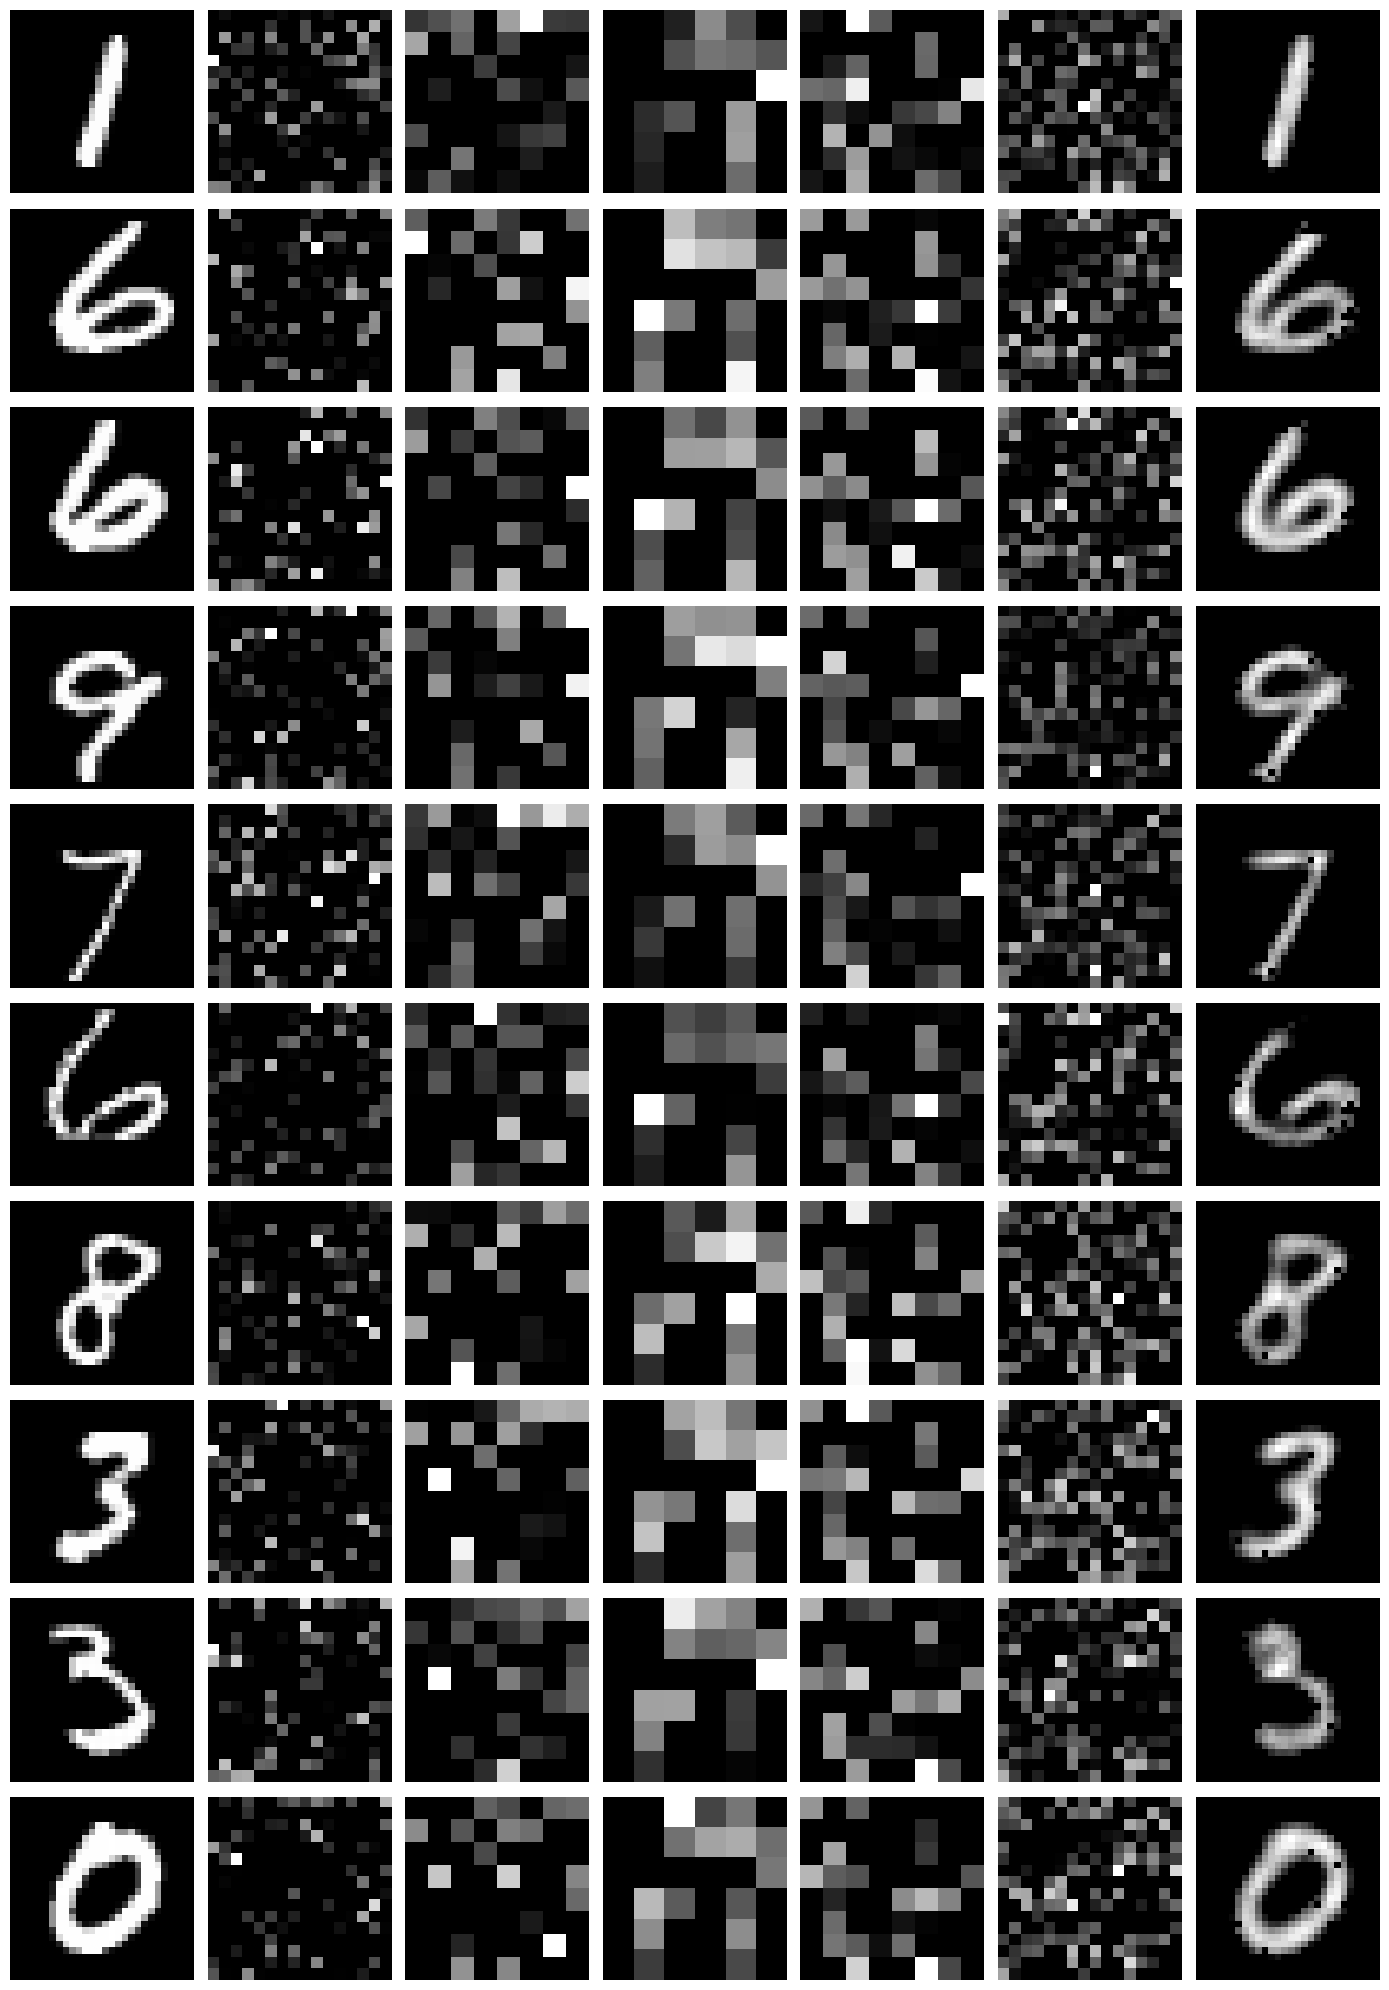

In [88]:
num_samples = 10
batch_inputs = x_test[np.random.randint(0, x_test.shape[0], size=num_samples)]
hidden1_output, hidden2_output, latent_output, hidden3_output, hidden4_output, output = forward(batch_inputs)

plot_outputs(batch_inputs, hidden1_output, hidden2_output, latent_output, hidden3_output, hidden4_output, output, num_samples)